In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
ruta_archivo = "../data/Base_de_datos.xlsx"
df = pd.read_excel(ruta_archivo)

In [3]:
df.isnull().sum()

tipo_credito                        0
fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
puntaje_datacredito                 6
cant_creditosvigentes               0
huella_consulta                     0
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
Pago_atiempo                        0
dtype: int64

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

In [5]:
df.head(10)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,...,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,...,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,...,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,...,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,...,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1
5,4,2025-06-10 08:54:01,1031928.0,12,32,Empleado,2800000,800000,82872,95.227787,...,0.0,24399.0,24399.0,0.0,2,0,8,2808474.0,Creciente,1
6,4,2025-08-09 13:00:44,3064280.4,6,68,Independiente,1000000,22005000,461231,95.227787,...,0.0,211775.0,211775.0,0.0,6,3,0,969508.0,Creciente,1
7,4,2025-08-18 12:49:19,3619560.0,6,31,Empleado,3782303,305000,542079,95.227787,...,0.0,12078.0,12078.0,0.0,0,1,0,3782303.0,Creciente,1
8,9,2025-05-30 09:11:18,2134827.6,10,31,Empleado,14500000,8000000,181732,95.227787,...,0.0,0.0,NaN,NaN,0,0,0,14007850.0,Creciente,1
9,4,2024-12-31 14:32:59,8400000.0,6,45,Empleado,14000000,5000000,1166667,95.227787,...,0.0,125383.0,125383.0,0.0,2,0,0,28889623.0,Creciente,1


In [6]:
columnas_a_borrar = [
    'tipo_credito', 
    'huella_consulta',
    'saldo_mora_codeudor', 
    'puntaje_datacredito', # Borramos este por ser redundante, pero CONSERVAMOS 'puntaje'
    'tendencia_ingresos',  # Borrada por tener casi 3000 nulos
    'saldo_mora',          # Borrada por fuga de información
    'saldo_total',         # Borrada por fuga de información
    'saldo_principal'      # Borrada por fuga de información
]

df = df.drop(columns=columnas_a_borrar, errors='ignore')

# Verificar que el dataset esté limpio de nulos
print(df.isnull().sum())

fecha_prestamo                      0
capital_prestado                    0
plazo_meses                         0
edad_cliente                        0
tipo_laboral                        0
salario_cliente                     0
total_otros_prestamos               0
cuota_pactada                       0
puntaje                             0
cant_creditosvigentes               0
creditos_sectorFinanciero           0
creditos_sectorCooperativo          0
creditos_sectorReal                 0
promedio_ingresos_datacredito    2930
Pago_atiempo                        0
dtype: int64


In [9]:
# Convertir a variable categórica
df['Pago_atiempo'] = df['Pago_atiempo'].astype('category')
df['tipo_laboral'] = df['tipo_laboral'].astype('category')

In [10]:
# Descripción estadística de variables numéricas
display(df.describe())

# Descripción de variables categóricas
display(df.describe(include=['category']))

,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,cant_creditosvigentes,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito
count,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10763.000000,10763.000000,10763.000000,10763.000000,7.833000e+03
mean,2025-04-16 23:06:02.111121,2.434315e+06,10.575583,43.948620,1.721643e+07,6.238870e+06,2.436174e+05,91.170036,5.726749,2.779987,0.269813,1.302704,2.005157e+06
min,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,-38.009990,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,3.000000,1.000000,0.000000,0.000000,9.251570e+05
50%,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,5.000000,2.000000,0.000000,1.000000,1.204496e+06
75%,2025-06-16 13:27:58,3.084840e+06,12.000000,53.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,8.000000,4.000000,0.000000,2.000000,2.231859e+06
max,2026-04-26 18:43:52,4.144415e+07,90.000000,123.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,62.000000,51.000000,13.000000,25.000000,3.810658e+07
std,NaN,1.909643e+06,6.632082,15.060877,3.554767e+08,1.184183e+08,2.104937e+05,16.465441,3.977162,2.748807,0.716471,1.824430,2.144116e+06


,tipo_laboral,Pago_atiempo
count,10763,10763
unique,2,2
top,Empleado,1
freq,6754,10252


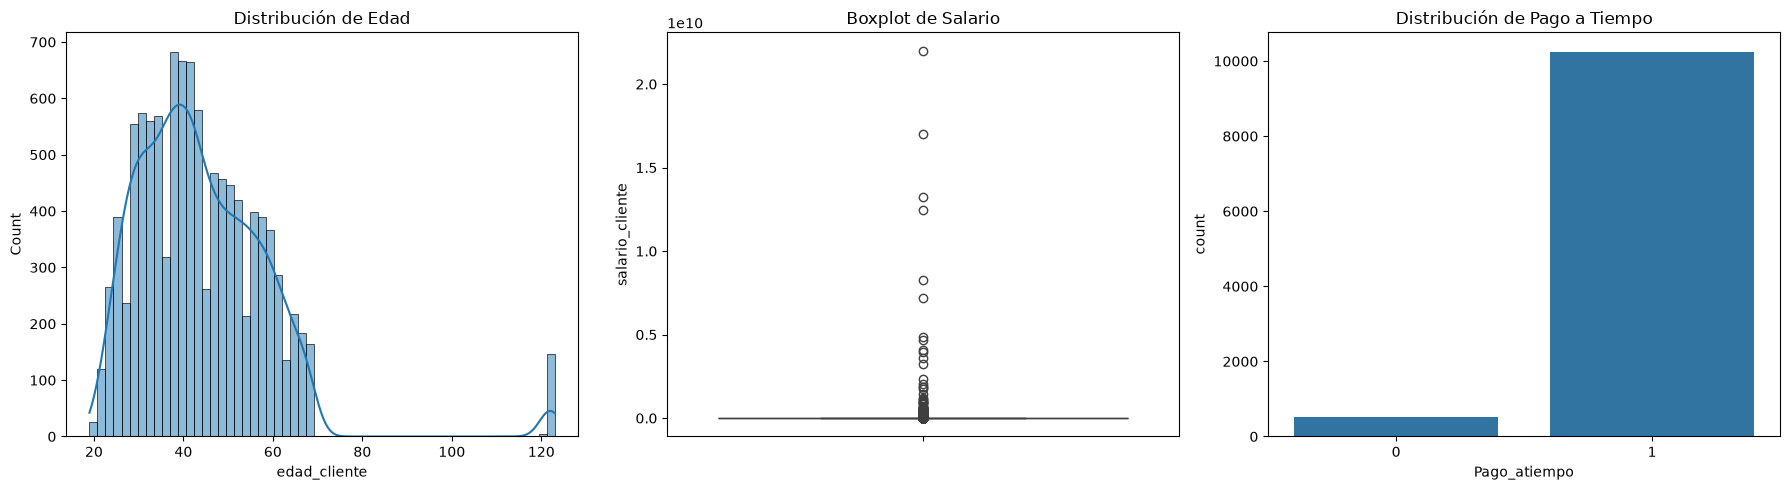

In [11]:


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma para distribución numérica
sns.histplot(df['edad_cliente'], kde=True, ax=axes[0])
axes[0].set_title('Distribución de Edad')

# Boxplot para detectar valores atípicos (outliers)
sns.boxplot(y=df['salario_cliente'], ax=axes[1])
axes[1].set_title('Boxplot de Salario')

# Countplot para variable categórica
sns.countplot(data=df, x='Pago_atiempo', ax=axes[2])
axes[2].set_title('Distribución de Pago a Tiempo')

plt.tight_layout()
plt.show()

Distribución de Edad del Cliente:

La gran mayoría del volumen de clientes se concentra en el rango de los 30 a los 50 años.
Observamos un pico anormal y aislado en la marca de los 120 años. Esto es claramente un error de captura o tipeo en el sistema de origen.
Para limpiar esto, será necesario implementar una regla de calidad de datos que exija un rango realista (por ejemplo, edad < 90 o edad < 100).

Boxplot de Salario del Cliente:

El gráfico de caja no se logra apreciar correctamente debido a una presencia extrema de valores atípicos (outliers) superiores.
Existen registros con salarios en el orden de los miles de millones, lo cual indica errores de digitación severos o una posible mezcla de distintas monedas en la misma columna.
Será indispensable aplicar recortes para definir un salario máximo aceptable, o bien aplicar una transformación logarítmica para reducir la escala de estos atípicos antes de entrenar un modelo.

Frecuencia de Pago a Tiempo:

Existe un desbalance de clases severo en esta variable (que es la variable objetivo). La inmensa mayoría de los registros pertenecen a la categoría "1", dejando a la categoría "0" con muy poca representatividad.
Este escenario es común en bases de datos de riesgos, pero requerirá técnicas de balanceo en la siguiente etapa del proyecto; de lo contrario, el modelo predictivo se sesgará a predecir siempre "1" ignorando los casos de mora.

C:\Users\Cristian\AppData\Local\Temp\ipykernel_1860\784877531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pago_atiempo', y='salario_cliente', ax=axes[0], palette='Set2')


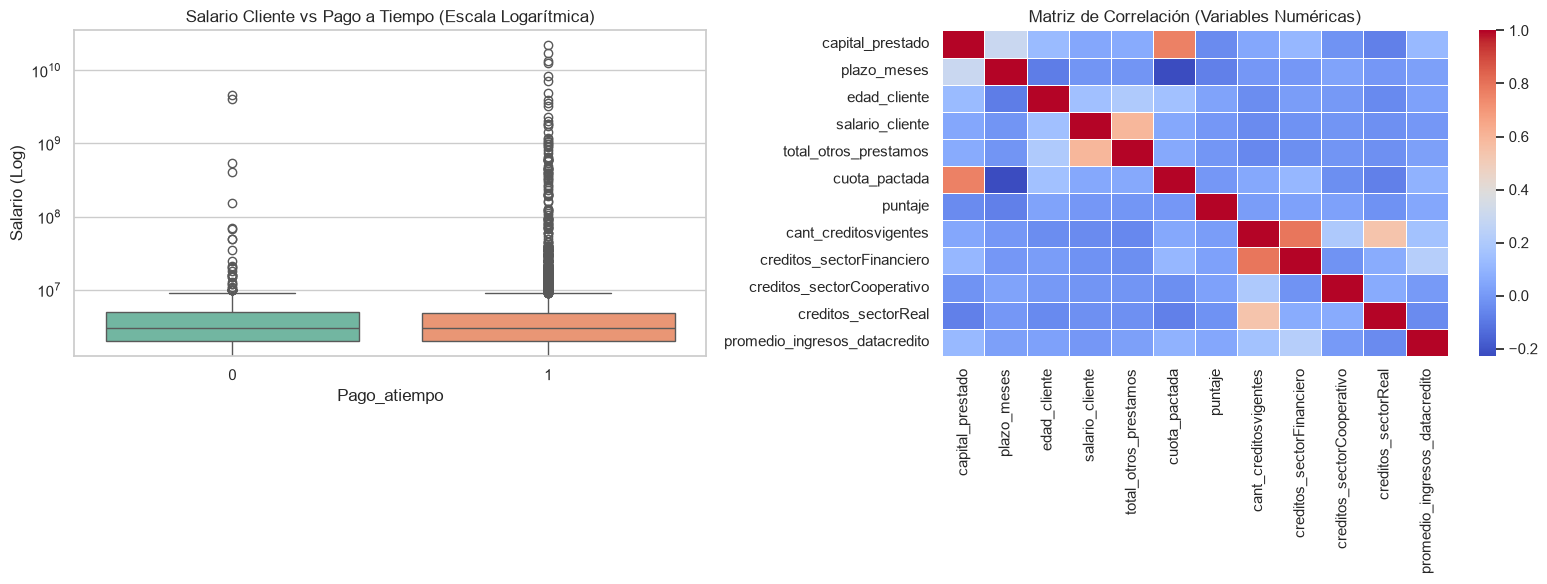

In [17]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ANÁLISIS BIVARIABLE: Salario vs Pago a tiempo (usando logaritmo por los outliers)
# Usamos un boxplot para ver si los que pagan a tiempo tienen salarios diferentes
sns.boxplot(data=df, x='Pago_atiempo', y='salario_cliente', ax=axes[0], palette='Set2')
axes[0].set_yscale('log') # Aplicamos escala logarítmica debido a los outliers extremos
axes[0].set_title('Salario Cliente vs Pago a Tiempo (Escala Logarítmica)')
axes[0].set_ylabel('Salario (Log)')

# 2. ANÁLISIS MULTIVARIABLE: Matriz de Correlación
# Solo seleccionamos las columnas numéricas para correlacionarlas
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
matriz_correlacion = df[columnas_numericas].corr()

# Graficamos un Heatmap
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de Correlación (Variables Numéricas)')

plt.tight_layout()
plt.show()

Análisis Bivariable: Salario Cliente vs Pago a Tiempo

Al aplicar la escala logarítmica, observamos que las distribuciones de salario para ambas categorías de pago (0 y 1) son prácticamente idénticas.
Las medianas (línea central de las cajas) y los rangos intercuartílicos están exactamente al mismo nivel. Esto demuestra que el monto del salario bruto, por sí solo, no es un factor fuertemente diferenciador para predecir si un cliente entrará en mora o pagará a tiempo.
Regla de validación: Ambos grupos conservan una densidad altísima de valores atípicos superiores, lo que ratifica la necesidad inminente de aplicar técnicas de escalado robusto o recorte en la etapa de preprocesamiento.

Análisis Multivariable: Matriz de Correlación

Existe una correlación positiva muy fuerte (cuadros rojos oscuros) entre capital_prestado y cuota_pactada. Esto es coherente con el negocio: a mayor préstamo, mayor es la cuota mensual asignada
Se evidencia una fuerte relación positiva entre cant_creditosvigentes y creditos_sectorFinanciero, lo que sugiere que la mayor parte del endeudamiento activo de la cartera de clientes proviene estrictamente del sector financiero tradicional.
La variable plazo_meses presenta una correlación negativa (tonos azules) con la cuota_pactada, confirmando la lógica financiera de que a mayor cantidad de meses de plazo, la cuota exigida tiende a disminuir.
Transformaciones futuras: Dado que capital_prestado y cuota_pactada están altamente correlacionadas, mantener ambas podría generar multicolinealidad. Se sugiere crear un atributo derivado (ej. "Relación Cuota/Ingreso" dividiendo la cuota por el salario) para consolidar la información predictiva de forma más eficiente.